# SC-Flow vs ContextFlow — Side-by-Side Comparison

Compares 100 runs of **sc-flow-tools** (CTF-H coupling) against 100 runs of the
original **ContextFlow** implementation on the GSE232025 axolotl dataset.

**Conditions compared:**
- `extrap_100` — Extrapolation (trained on Stage44→Stage54→Stage57→Juvenile, predict Adult)
- `intrap_100` — Interpolation (trained on Stage44→Stage54→Stage57→Adult, predict Juvenile)

**Metrics:** Sliced Wasserstein (W2), MMD, Energy distance  
**Prediction modes:** Next-Step (NS) and IVP (full trajectory from t=0 to t_end)

Each panel shows: **mean ± std** across 100 seeds, per transition.

In [15]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D

In [16]:
# ── Paths ────────────────────────────────────────────────────────────────────
SCFLOW_RESULTS  = "results"                  # relative to this notebook
CTF_BASE        = "/scratch/icbb/vishak/contextflow/contextflow_orig/ContextFlow/experiment_figures/use_all_data_False_GSE232025"

N_RUNS = 100

TRANSITIONS = [
    "Stage44 -> Stage54",
    "Stage54 -> Stage57",
    "Stage57 -> Juvenile",
    "Juvenile -> Adult",
]
N_TRANS = len(TRANSITIONS)

METRICS = ["W2", "MMD", "Energy"]

# Dark shade = sc-flow-tools, light shade = ContextFlow (same hue = same metric)
SF_COLORS  = {"W2": "#1565C0", "MMD": "#BF360C", "Energy": "#2E7D32"}   # dark
CTF_COLORS = {"W2": "#90CAF9", "MMD": "#FFAB91", "Energy": "#A5D6A7"}   # light

MARKERS = {"W2": "o", "MMD": "s", "Energy": "^"}

# Functions

In [17]:
def load_scflow_runs(condition: str, csv_name: str) -> dict[str, np.ndarray]:
    """Load sc-flow-tools CSV results across N_RUNS runs.

    Returns dict: metric -> array of shape (N_TRANS, n_valid_runs)
    """
    data = {m: [] for m in METRICS}
    base = os.path.join(SCFLOW_RESULTS, condition)
    for run_id in range(N_RUNS):
        path = os.path.join(base, f"run_{run_id}", csv_name)
        if not os.path.exists(path):
            continue
        df = pd.read_csv(path).set_index("transition").reindex(TRANSITIONS)
        if df.isnull().all().any():
            continue
        data["W2"].append(df["W2 (model)"].values)
        data["MMD"].append(df["MMD (model)"].values)
        data["Energy"].append(df["Energy (model)"].values)
    return {m: np.array(v).T for m, v in data.items()}


def load_ctf_runs(
    prefix: str,
    json_name: str,
    subfolder: str = "Default",
    ivp: bool = False,
) -> dict[str, np.ndarray]:
    """Load ContextFlow JSON results from folders named f'{prefix}_{i}' for i in 1..N_RUNS.

    subfolder: result subfolder within each run dir ('Default' or 'relative_default').
    ivp=True: skips the trivial t=0 entry and takes indices [1:5].

    Returns dict: metric -> array of shape (N_TRANS, n_valid_runs)
    """
    CTF_METRIC_MAP = {"W2": "wasserstein", "MMD": "mmd", "Energy": "energy"}
    data = {m: [] for m in METRICS}
    for i in range(1, N_RUNS + 1):
        path = os.path.join(CTF_BASE, f"{prefix}_{i}", subfolder, json_name)
        if not os.path.exists(path):
            continue
        with open(path) as f:
            j = json.load(f)
        try:
            for m in METRICS:
                vals = j[CTF_METRIC_MAP[m]]
                if ivp:
                    vals = vals[1:5]
                if len(vals) != N_TRANS:
                    continue
                data[m].append(vals)
        except (KeyError, IndexError):
            continue
    return {m: np.array(v).T for m, v in data.items()}


def plot_combined_overview(
    combos: list[tuple],
    suptitle: str,
    save_path: str,
    sf_label: str = "sc-flow-tools (dark, solid)",
    ctf_label: str = "ContextFlow (light, dashed)",
):
    """Plot a 2×2 grid comparing sc-flow-tools vs a baseline across 4 conditions.

    combos: list of (sf_data, ctf_data, panel_title) — row-major order.
    """
    fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharey=False)
    x = np.arange(N_TRANS)
    xlabels = [t.replace(" -> ", "\n→ ") for t in TRANSITIONS]

    for ax, (sf, ctf, title) in zip(axes.flat, combos):
        for metric in METRICS:
            sf_color  = SF_COLORS[metric]
            ctf_color = CTF_COLORS[metric]
            marker    = MARKERS[metric]

            sf_mean, sf_std = sf[metric].mean(axis=1), sf[metric].std(axis=1)
            ax.plot(x, sf_mean, color=sf_color, lw=2.5, marker=marker, ms=6,
                    linestyle="-", zorder=3)
            ax.fill_between(x, sf_mean - sf_std, sf_mean + sf_std,
                            color=sf_color, alpha=0.18)

            ctf_mean, ctf_std = ctf[metric].mean(axis=1), ctf[metric].std(axis=1)
            ax.plot(x, ctf_mean, color=ctf_color, lw=2.5, marker=marker, ms=6,
                    linestyle="--", markeredgecolor=sf_color, markeredgewidth=1.2, zorder=2)
            ax.fill_between(x, ctf_mean - ctf_std, ctf_mean + ctf_std,
                            color=ctf_color, alpha=0.22)

        ax.set_xticks(x)
        ax.set_xticklabels(xlabels, fontsize=8)
        ax.set_title(title, fontsize=10, fontweight="bold")
        ax.set_ylabel("Metric value")
        ax.grid(axis="y", linestyle="--", alpha=0.35)

    metric_handles = [
        Line2D([0], [0], color=SF_COLORS[m], lw=2.5, marker=MARKERS[m], ms=6, label=m)
        for m in METRICS
    ]
    style_handles = [
        Line2D([0], [0], color="#444", lw=2.5, linestyle="-",  marker="o", ms=5, label=sf_label),
        Line2D([0], [0], color="#AAA", lw=2.5, linestyle="--", marker="o", ms=5,
               markeredgecolor="#444", markeredgewidth=1.2, label=ctf_label),
    ]
    fig.legend(handles=metric_handles + style_handles, loc="lower center",
               ncol=5, fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.04))
    fig.suptitle(suptitle, fontsize=13, fontweight="bold", y=1.01)
    fig.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")

In [18]:
# ── Load everything ──────────────────────────────────────────────────────────
print("Loading sc-flow-tools results...")
sf_extrap_ns  = load_scflow_runs("extrapolation",  "metrics_ns.csv")
sf_extrap_ivp = load_scflow_runs("extrapolation",  "metrics_ivp.csv")
sf_interp_ns  = load_scflow_runs("interpolation",  "metrics_ns.csv")
sf_interp_ivp = load_scflow_runs("interpolation",  "metrics_ivp.csv")

print("Loading ContextFlow results...")
ctf_extrap_ns  = load_ctf_runs("extrap_100", "next_step_error.json", ivp=False)
ctf_extrap_ivp = load_ctf_runs("extrap_100", "IVP_error.json",       ivp=True)
ctf_interp_ns  = load_ctf_runs("interp_100", "next_step_error.json", ivp=False)
ctf_interp_ivp = load_ctf_runs("interp_100", "IVP_error.json",       ivp=True)

# Print run counts
for label, d in [
    ("SF extrap NS",  sf_extrap_ns),
    ("SF extrap IVP", sf_extrap_ivp),
    ("SF interp NS",  sf_interp_ns),
    ("SF interp IVP", sf_interp_ivp),
    ("CTF extrap NS",  ctf_extrap_ns),
    ("CTF extrap IVP", ctf_extrap_ivp),
    ("CTF interp NS",  ctf_interp_ns),
    ("CTF interp IVP", ctf_interp_ivp),
]:
    n = d["W2"].shape[1] if d["W2"].size else 0
    print(f"  {label}: {n} runs")

Loading sc-flow-tools results...
Loading ContextFlow results...
  SF extrap NS: 100 runs
  SF extrap IVP: 100 runs
  SF interp NS: 100 runs
  SF interp IVP: 100 runs
  CTF extrap NS: 97 runs
  CTF extrap IVP: 97 runs
  CTF interp NS: 98 runs
  CTF interp IVP: 98 runs


# Results: SC-Flow vs Original ContextFlow

## Combined 4-panel Overview

Rows = (Extrap, Interp) × cols = (NS, IVP); all three metrics (W2, MMD, Energy) overlaid.

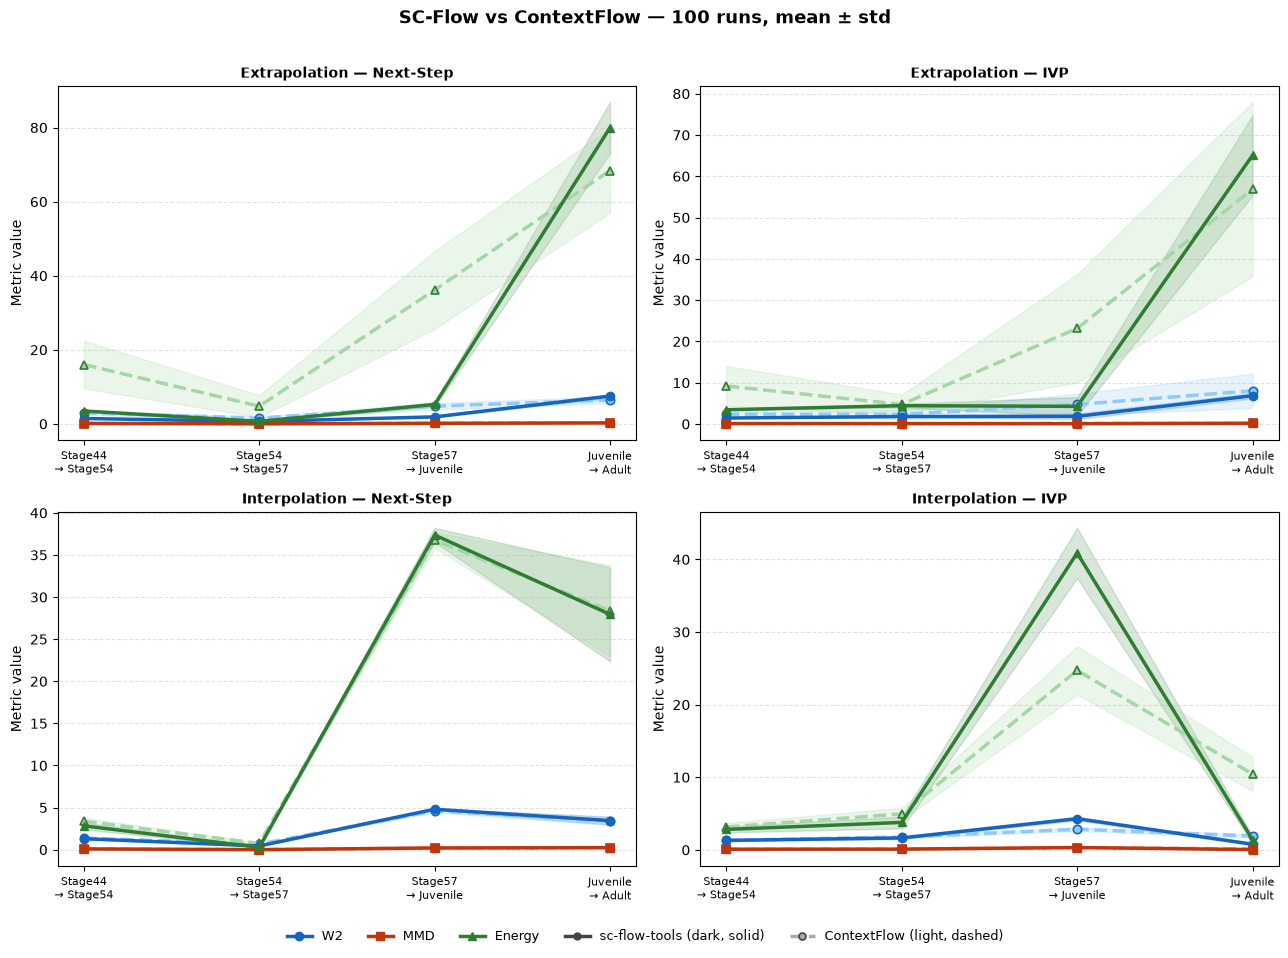

Saved: results/comparison_overview.png


In [19]:
plot_combined_overview(
    combos=[
        (sf_extrap_ns,  ctf_extrap_ns,  "Extrapolation — Next-Step"),
        (sf_extrap_ivp, ctf_extrap_ivp, "Extrapolation — IVP"),
        (sf_interp_ns,  ctf_interp_ns,  "Interpolation — Next-Step"),
        (sf_interp_ivp, ctf_interp_ivp, "Interpolation — IVP"),
    ],
    suptitle="SC-Flow vs ContextFlow — 100 runs, mean ± std",
    save_path=os.path.join(SCFLOW_RESULTS, "comparison_overview.png"),
)

# Relative Comparison — SC-Flow (CTF-H params) vs ContextFlow

Uses sc-flow-tools runs with **matching CTF-H hyperparameters** (`eps=100`, `λ=0.4`, same as ContextFlow).
This is the apples-to-apples comparison: same coupling, same data, different framework.

- `relative_extrapolation` — trained on Stage44→Stage54→Stage57→Juvenile, predict Adult  
- `relative_interpolation` — trained on Stage44→Stage54→Stage57→Adult (Juvenile skipped), predict Juvenile

In [20]:
# ── Load relative sc-flow results (CTF-H hyperparams matching ContextFlow) ────
print("Loading relative sc-flow-tools results...")
sf_rel_extrap_ns  = load_scflow_runs("relative_extrapolation", "metrics_ns.csv")
sf_rel_extrap_ivp = load_scflow_runs("relative_extrapolation", "metrics_ivp.csv")
sf_rel_interp_ns  = load_scflow_runs("relative_interpolation", "metrics_ns.csv")
sf_rel_interp_ivp = load_scflow_runs("relative_interpolation", "metrics_ivp.csv")

for label, d in [
    ("SF rel extrap NS",  sf_rel_extrap_ns),
    ("SF rel extrap IVP", sf_rel_extrap_ivp),
    ("SF rel interp NS",  sf_rel_interp_ns),
    ("SF rel interp IVP", sf_rel_interp_ivp),
]:
    n = d["W2"].shape[1] if d["W2"].size else 0
    print(f"  {label}: {n} runs")

Loading relative sc-flow-tools results...


  SF rel extrap NS: 85 runs
  SF rel extrap IVP: 85 runs
  SF rel interp NS: 55 runs
  SF rel interp IVP: 55 runs


## Relative — Combined 4-panel Overview

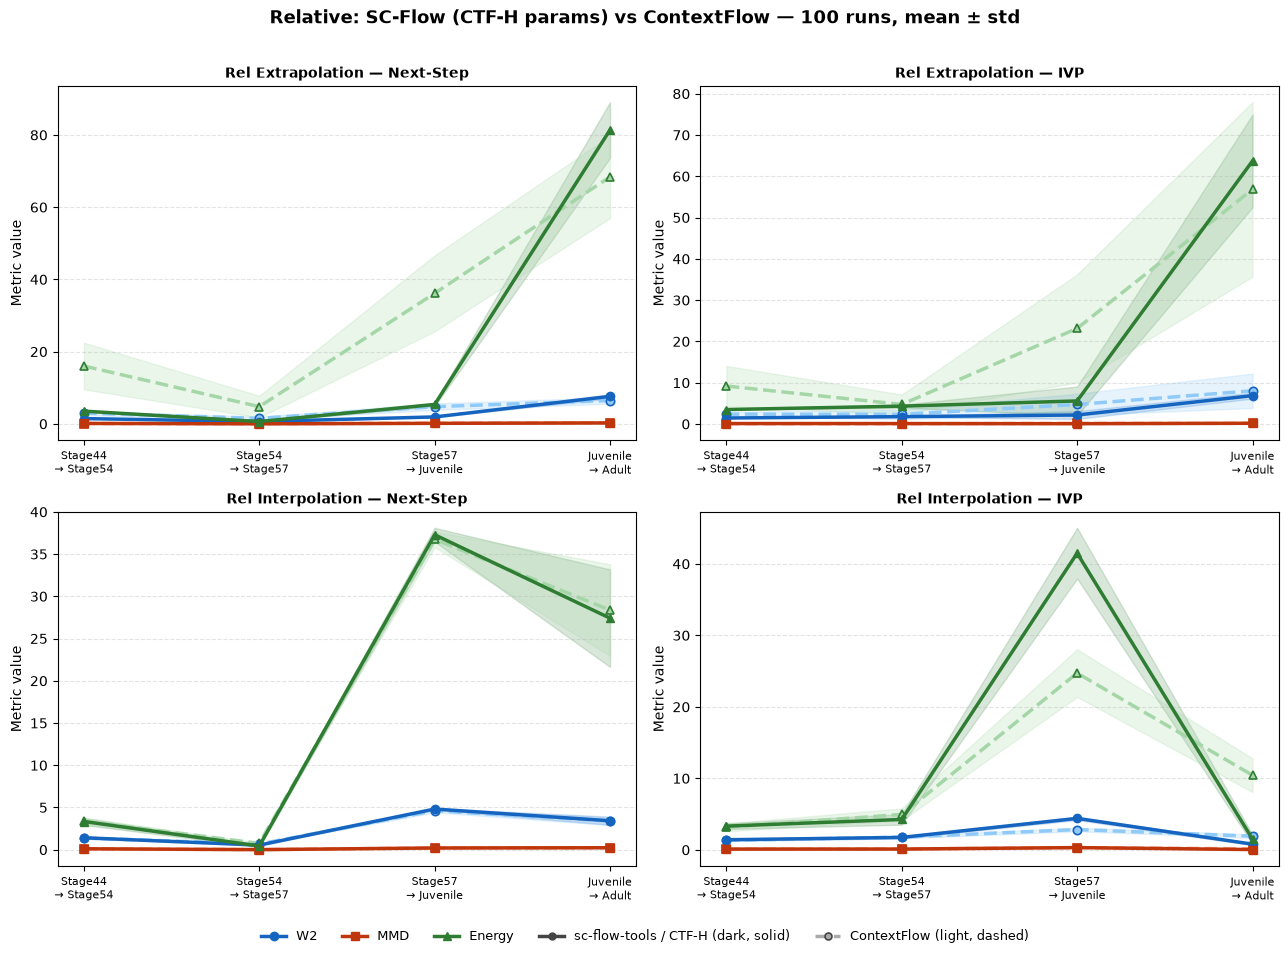

Saved: results/relative_comparison_overview.png


In [21]:
plot_combined_overview(
    combos=[
        (sf_rel_extrap_ns,  ctf_extrap_ns,  "Rel Extrapolation — Next-Step"),
        (sf_rel_extrap_ivp, ctf_extrap_ivp, "Rel Extrapolation — IVP"),
        (sf_rel_interp_ns,  ctf_interp_ns,  "Rel Interpolation — Next-Step"),
        (sf_rel_interp_ivp, ctf_interp_ivp, "Rel Interpolation — IVP"),
    ],
    suptitle="Relative: SC-Flow (CTF-H params) vs ContextFlow — 100 runs, mean ± std",
    save_path=os.path.join(SCFLOW_RESULTS, "relative_comparison_overview.png"),
    sf_label="sc-flow-tools / CTF-H (dark, solid)",
)

# NEW ContextFlow Redo — SC-Flow vs Rerun ContextFlow

Redo of all ContextFlow runs using the same experimental setup.
Result folders are prefixed `NEW_` in the experiment directory.

**Available redo runs:**
- `NEW_extrap_100` — Extrapolation redo (95 runs, `Default` subfolder)
- `NEW_interp_100` — Interpolation redo (98 runs, `Default` subfolder)
- `NEW_relative_interp_100` — Relative interpolation redo (98 runs, `relative_default` subfolder)
- `NEW_relative_extrap_100` — Relative extrapolation redo (only 6 runs, evaluation not yet complete — skipped)

Comparing sc-flow-tools results against the **new** ContextFlow runs.

In [22]:
print("Loading NEW ContextFlow results...")
new_ctf_extrap_ns  = load_ctf_runs("NEW_extrap_100", "next_step_error.json", ivp=False)
new_ctf_extrap_ivp = load_ctf_runs("NEW_extrap_100", "IVP_error.json",       ivp=True)
new_ctf_interp_ns  = load_ctf_runs("NEW_interp_100", "next_step_error.json", ivp=False)
new_ctf_interp_ivp = load_ctf_runs("NEW_interp_100", "IVP_error.json",       ivp=True)

new_ctf_rel_interp_ns  = load_ctf_runs("NEW_relative_interp_100", "next_step_error.json", subfolder="relative_default", ivp=False)
new_ctf_rel_interp_ivp = load_ctf_runs("NEW_relative_interp_100", "IVP_error.json",       subfolder="relative_default", ivp=True)

for label, d in [
    ("NEW CTF extrap NS",      new_ctf_extrap_ns),
    ("NEW CTF extrap IVP",     new_ctf_extrap_ivp),
    ("NEW CTF interp NS",      new_ctf_interp_ns),
    ("NEW CTF interp IVP",     new_ctf_interp_ivp),
    ("NEW CTF rel interp NS",  new_ctf_rel_interp_ns),
    ("NEW CTF rel interp IVP", new_ctf_rel_interp_ivp),
]:
    n = d["W2"].shape[1] if d["W2"].size else 0
    print(f"  {label}: {n} runs")

Loading NEW ContextFlow results...


  NEW CTF extrap NS: 95 runs
  NEW CTF extrap IVP: 95 runs
  NEW CTF interp NS: 98 runs
  NEW CTF interp IVP: 98 runs
  NEW CTF rel interp NS: 98 runs
  NEW CTF rel interp IVP: 98 runs


## NEW CTF — Combined 4-panel Overview (Extrap + Interp)

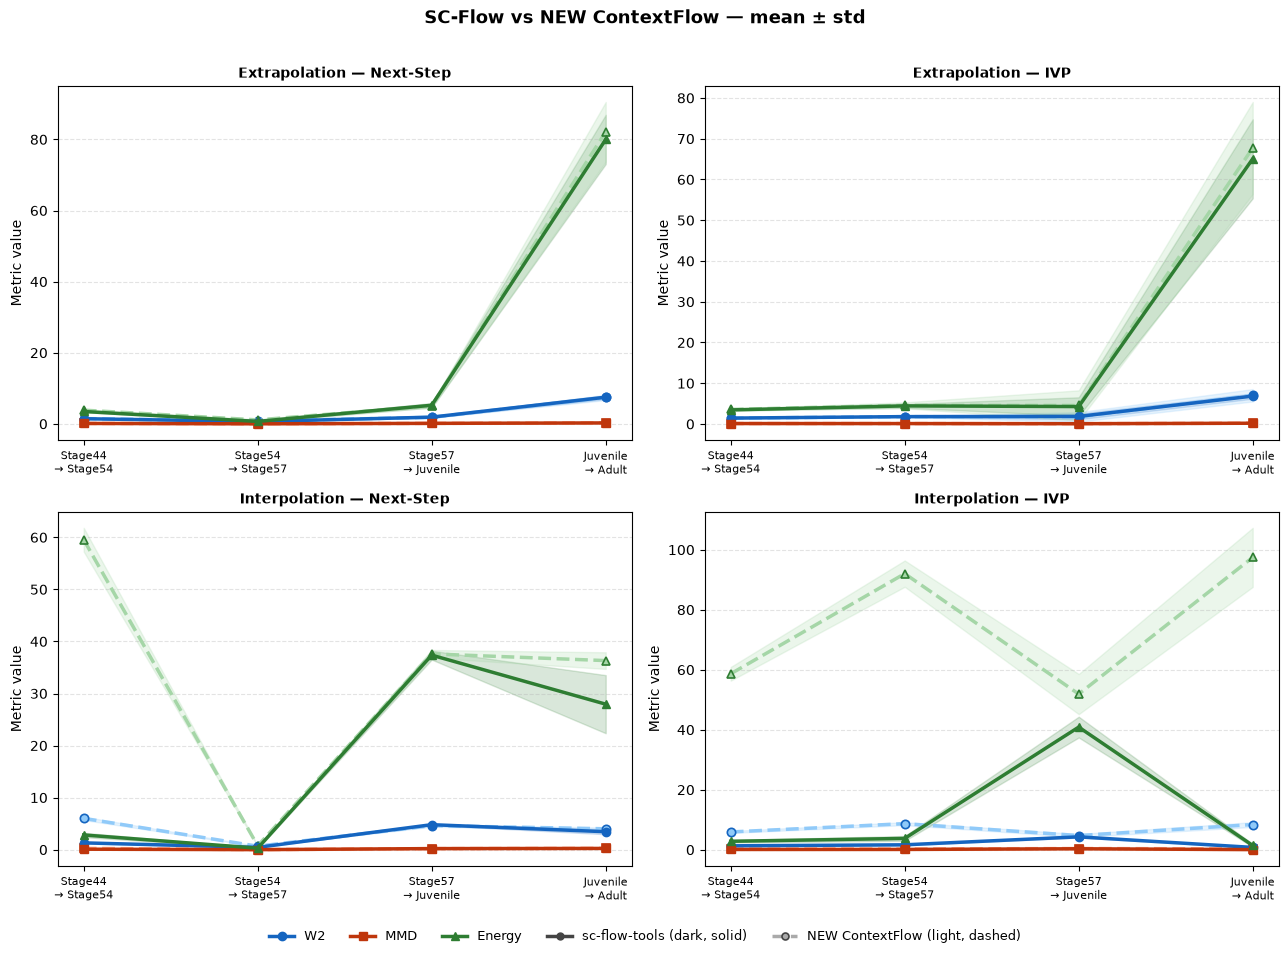

Saved: results/new_ctf_comparison_overview.png


In [23]:
plot_combined_overview(
    combos=[
        (sf_extrap_ns,  new_ctf_extrap_ns,  "Extrapolation — Next-Step"),
        (sf_extrap_ivp, new_ctf_extrap_ivp, "Extrapolation — IVP"),
        (sf_interp_ns,  new_ctf_interp_ns,  "Interpolation — Next-Step"),
        (sf_interp_ivp, new_ctf_interp_ivp, "Interpolation — IVP"),
    ],
    suptitle="SC-Flow vs NEW ContextFlow — mean ± std",
    save_path=os.path.join(SCFLOW_RESULTS, "new_ctf_comparison_overview.png"),
    ctf_label="NEW ContextFlow (light, dashed)",
)

# NEW_NEW ContextFlow Redo — SC-Flow vs Rerun ContextFlow (Second Batch)

Second redo batch of ContextFlow runs.
Result folders are prefixed `NEW_NEW_` in the experiment directory.

**Available redo runs:**
- `NEW_NEW_extrap_100` — Extrapolation redo (100 runs, `Default` subfolder)
- `NEW_NEW_interp_100` — Interpolation redo (100 runs, `Default` subfolder)
- `NEW_NEW_relative_extrap_100` — Relative extrapolation redo (99/100 runs complete, `relative_default` subfolder)
- `NEW_NEW_relative_interp_100` — Relative interpolation redo (in progress, `relative_default` subfolder)

Comparing sc-flow-tools results against the **NEW_NEW** ContextFlow runs.

In [24]:
print("Loading NEW_NEW ContextFlow results...")
new_new_ctf_extrap_ns  = load_ctf_runs("NEW_NEW_extrap_100", "next_step_error.json", ivp=False)
new_new_ctf_extrap_ivp = load_ctf_runs("NEW_NEW_extrap_100", "IVP_error.json",       ivp=True)
new_new_ctf_interp_ns  = load_ctf_runs("NEW_NEW_interp_100", "next_step_error.json", ivp=False)
new_new_ctf_interp_ivp = load_ctf_runs("NEW_NEW_interp_100", "IVP_error.json",       ivp=True)

# Relative extrap: 99/100 done (run 28 missing IVP_error.json)
# Relative interp: in progress, loads however many exist
new_new_ctf_rel_extrap_ns  = load_ctf_runs("NEW_NEW_relative_extrap_100", "next_step_error.json", subfolder="relative_default", ivp=False)
new_new_ctf_rel_extrap_ivp = load_ctf_runs("NEW_NEW_relative_extrap_100", "IVP_error.json",       subfolder="relative_default", ivp=True)
new_new_ctf_rel_interp_ns  = load_ctf_runs("NEW_NEW_relative_interp_100", "next_step_error.json", subfolder="relative_default", ivp=False)
new_new_ctf_rel_interp_ivp = load_ctf_runs("NEW_NEW_relative_interp_100", "IVP_error.json",       subfolder="relative_default", ivp=True)

for label, d in [
    ("NEW_NEW CTF extrap NS",       new_new_ctf_extrap_ns),
    ("NEW_NEW CTF extrap IVP",      new_new_ctf_extrap_ivp),
    ("NEW_NEW CTF interp NS",       new_new_ctf_interp_ns),
    ("NEW_NEW CTF interp IVP",      new_new_ctf_interp_ivp),
    ("NEW_NEW CTF rel extrap NS",   new_new_ctf_rel_extrap_ns),
    ("NEW_NEW CTF rel extrap IVP",  new_new_ctf_rel_extrap_ivp),
    ("NEW_NEW CTF rel interp NS",   new_new_ctf_rel_interp_ns),
    ("NEW_NEW CTF rel interp IVP",  new_new_ctf_rel_interp_ivp),
]:
    n = d["W2"].shape[1] if d["W2"].size else 0
    print(f"  {label}: {n} runs")

Loading NEW_NEW ContextFlow results...
  NEW_NEW CTF extrap NS: 96 runs
  NEW_NEW CTF extrap IVP: 96 runs
  NEW_NEW CTF interp NS: 100 runs
  NEW_NEW CTF interp IVP: 100 runs
  NEW_NEW CTF rel extrap NS: 99 runs
  NEW_NEW CTF rel extrap IVP: 99 runs
  NEW_NEW CTF rel interp NS: 30 runs
  NEW_NEW CTF rel interp IVP: 29 runs


## NEW_NEW CTF — Combined 4-panel Overview (Extrap + Interp)

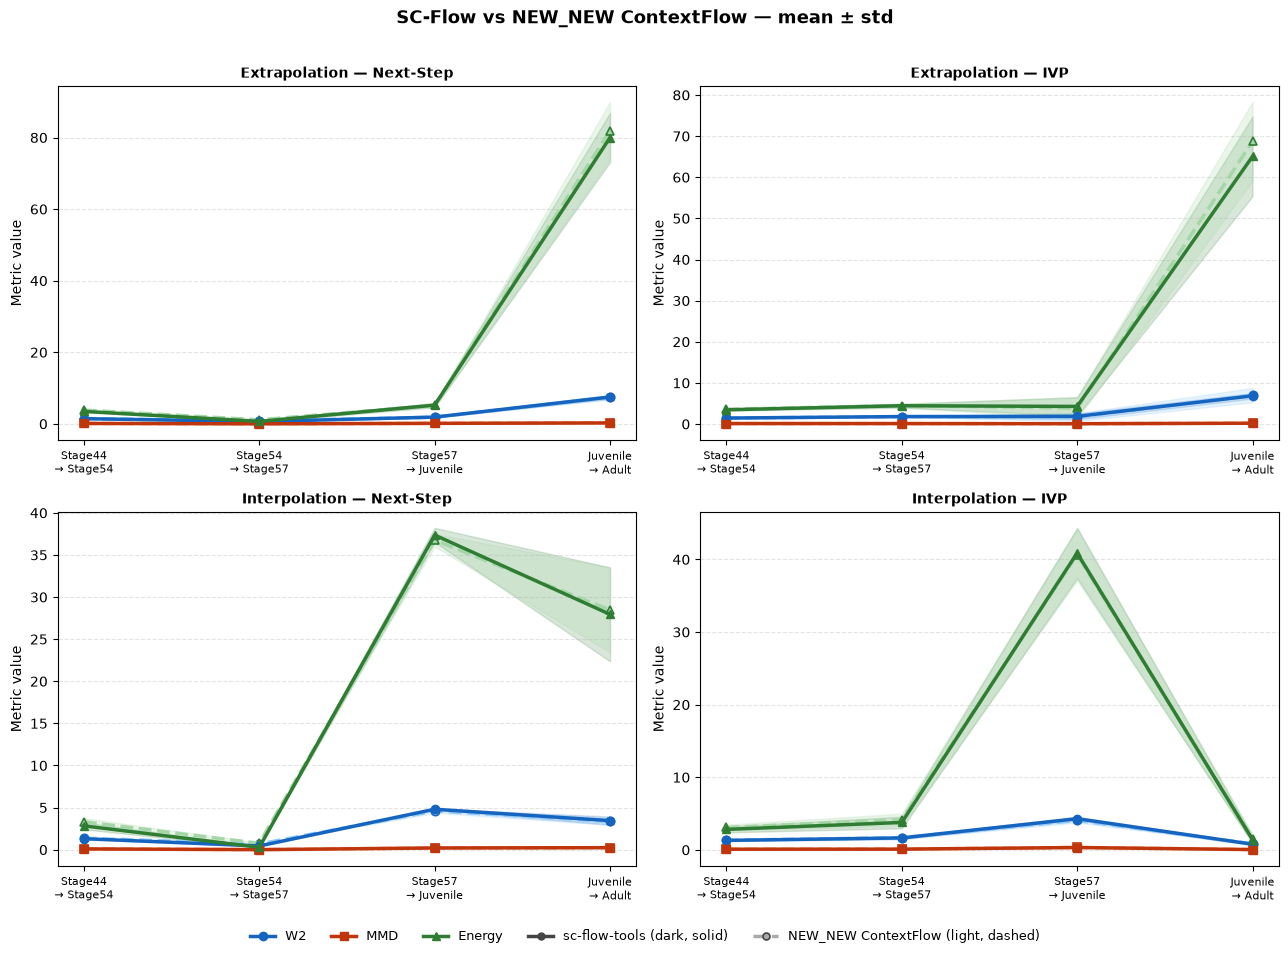

Saved: results/new_new_ctf_comparison_overview.png


In [25]:
plot_combined_overview(
    combos=[
        (sf_extrap_ns,  new_new_ctf_extrap_ns,  "Extrapolation — Next-Step"),
        (sf_extrap_ivp, new_new_ctf_extrap_ivp, "Extrapolation — IVP"),
        (sf_interp_ns,  new_new_ctf_interp_ns,  "Interpolation — Next-Step"),
        (sf_interp_ivp, new_new_ctf_interp_ivp, "Interpolation — IVP"),
    ],
    suptitle="SC-Flow vs NEW_NEW ContextFlow — mean ± std",
    save_path=os.path.join(SCFLOW_RESULTS, "new_new_ctf_comparison_overview.png"),
    ctf_label="NEW_NEW ContextFlow (light, dashed)",
)

## NEW_NEW CTF — Relative Comparison (extrap 99/100, interp in progress)

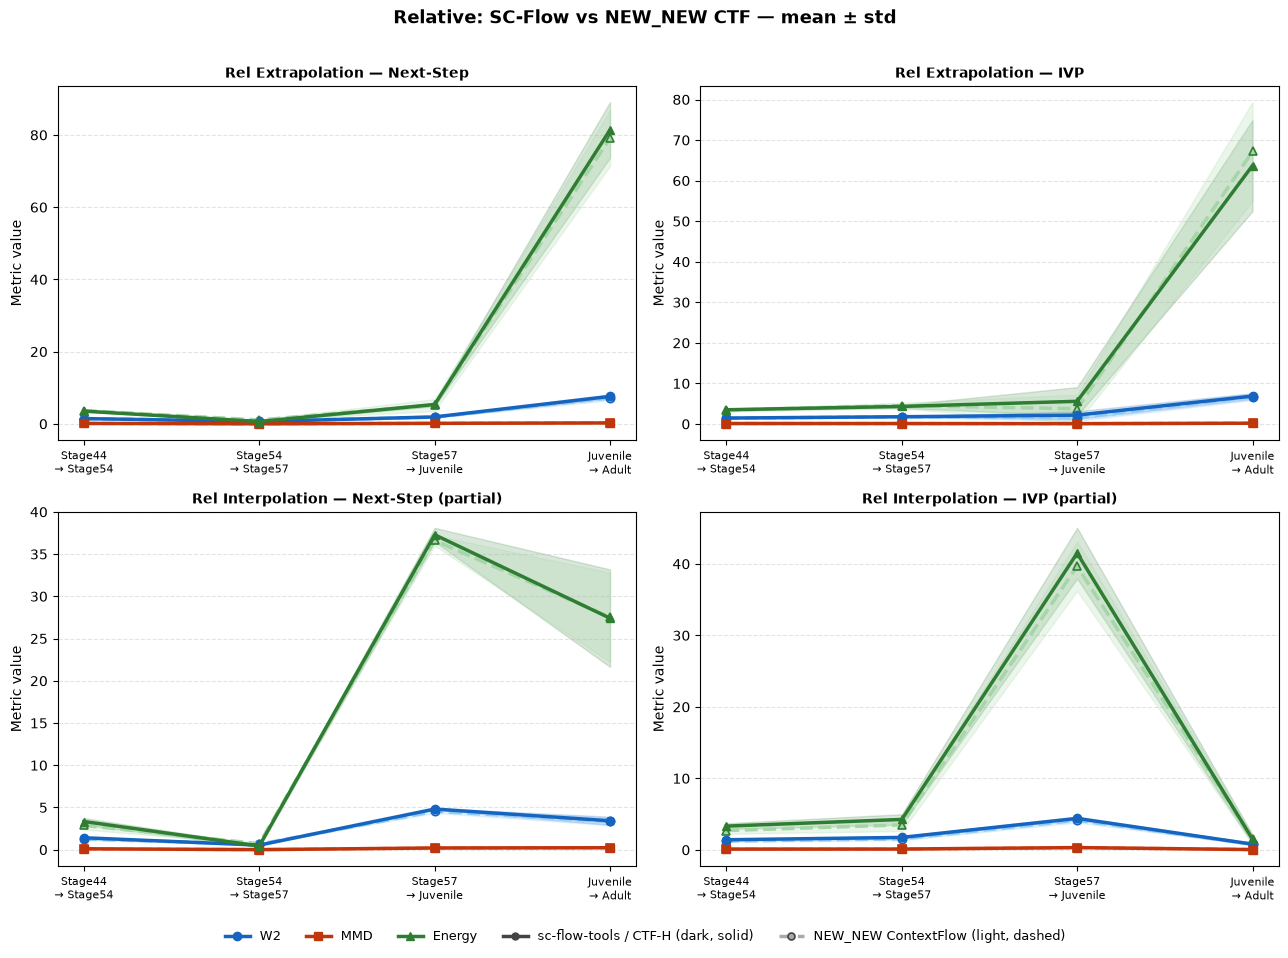

Saved: results/new_new_ctf_relative_comparison_overview.png


In [26]:
plot_combined_overview(
    combos=[
        (sf_rel_extrap_ns,  new_new_ctf_rel_extrap_ns,  "Rel Extrapolation — Next-Step"),
        (sf_rel_extrap_ivp, new_new_ctf_rel_extrap_ivp, "Rel Extrapolation — IVP"),
        (sf_rel_interp_ns,  new_new_ctf_rel_interp_ns,  "Rel Interpolation — Next-Step (partial)"),
        (sf_rel_interp_ivp, new_new_ctf_rel_interp_ivp, "Rel Interpolation — IVP (partial)"),
    ],
    suptitle="Relative: SC-Flow vs NEW_NEW CTF — mean ± std",
    save_path=os.path.join(SCFLOW_RESULTS, "new_new_ctf_relative_comparison_overview.png"),
    sf_label="sc-flow-tools / CTF-H (dark, solid)",
    ctf_label="NEW_NEW ContextFlow (light, dashed)",
)

# NEW_NEW ContextFlow — Standalone Results

ContextFlow NEW_NEW runs on their own (no sc-flow overlay).
Shows mean ± std across runs for each metric and transition.

- Extrap/Interp: ~96–100 runs complete
- Relative extrap: 99/100 runs complete
- Relative interp: in progress (partial)

In [30]:
print("Loading NEW_NEW ContextFlow results (standalone section)...")
nn_extrap_ns  = load_ctf_runs("NEW_NEW_extrap_100", "next_step_error.json", ivp=False)
nn_extrap_ivp = load_ctf_runs("NEW_NEW_extrap_100", "IVP_error.json",       ivp=True)
nn_interp_ns  = load_ctf_runs("NEW_NEW_interp_100", "next_step_error.json", ivp=False)
nn_interp_ivp = load_ctf_runs("NEW_NEW_interp_100", "IVP_error.json",       ivp=True)
nn_rel_extrap_ns  = load_ctf_runs("NEW_NEW_relative_extrap_100", "next_step_error.json", subfolder="relative_default", ivp=False)
nn_rel_extrap_ivp = load_ctf_runs("NEW_NEW_relative_extrap_100", "IVP_error.json",       subfolder="relative_default", ivp=True)
nn_rel_interp_ns  = load_ctf_runs("NEW_NEW_relative_interp_100", "next_step_error.json", subfolder="relative_default", ivp=False)
nn_rel_interp_ivp = load_ctf_runs("NEW_NEW_relative_interp_100", "IVP_error.json",       subfolder="relative_default", ivp=True)

for label, d in [
    ("extrap NS",       nn_extrap_ns),
    ("extrap IVP",      nn_extrap_ivp),
    ("interp NS",       nn_interp_ns),
    ("interp IVP",      nn_interp_ivp),
    ("rel extrap NS",   nn_rel_extrap_ns),
    ("rel extrap IVP",  nn_rel_extrap_ivp),
    ("rel interp NS",   nn_rel_interp_ns),
    ("rel interp IVP",  nn_rel_interp_ivp),
]:
    n = d["W2"].shape[1] if d["W2"].size else 0
    print(f"  {label}: {n} runs")

Loading NEW_NEW ContextFlow results (standalone section)...
  extrap NS: 96 runs
  extrap IVP: 96 runs
  interp NS: 100 runs
  interp IVP: 100 runs
  rel extrap NS: 99 runs
  rel extrap IVP: 99 runs
  rel interp NS: 32 runs
  rel interp IVP: 32 runs


In [31]:
def plot_ctf_standalone(
    panels: list[tuple],
    suptitle: str,
    save_path: str,
):
    """Plot a 2×2 grid of standalone ContextFlow results (mean ± std, no overlay).

    panels: list of (ctf_data, panel_title)
    """
    fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharey=False)
    x = np.arange(N_TRANS)
    xlabels = [t.replace(" -> ", "\n→ ") for t in TRANSITIONS]

    for ax, (ctf, title) in zip(axes.flat, panels):
        n_runs = ctf["W2"].shape[1] if ctf["W2"].size else 0
        for metric in METRICS:
            color  = SF_COLORS[metric]   # use the dark palette for standalone
            marker = MARKERS[metric]
            mean = ctf[metric].mean(axis=1)
            std  = ctf[metric].std(axis=1)
            ax.plot(x, mean, color=color, lw=2.5, marker=marker, ms=6, zorder=3)
            ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.18)

        ax.set_xticks(x)
        ax.set_xticklabels(xlabels, fontsize=8)
        ax.set_title(f"{title}  (n={n_runs})", fontsize=10, fontweight="bold")
        ax.set_ylabel("Metric value")
        ax.grid(axis="y", linestyle="--", alpha=0.35)

    legend_handles = [
        Line2D([0], [0], color=SF_COLORS[m], lw=2.5, marker=MARKERS[m], ms=6, label=m)
        for m in METRICS
    ]
    fig.legend(handles=legend_handles, loc="lower center",
               ncol=3, fontsize=10, frameon=False, bbox_to_anchor=(0.5, -0.03))
    fig.suptitle(suptitle, fontsize=13, fontweight="bold", y=1.01)
    fig.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")

## Extrapolation & Interpolation (absolute)

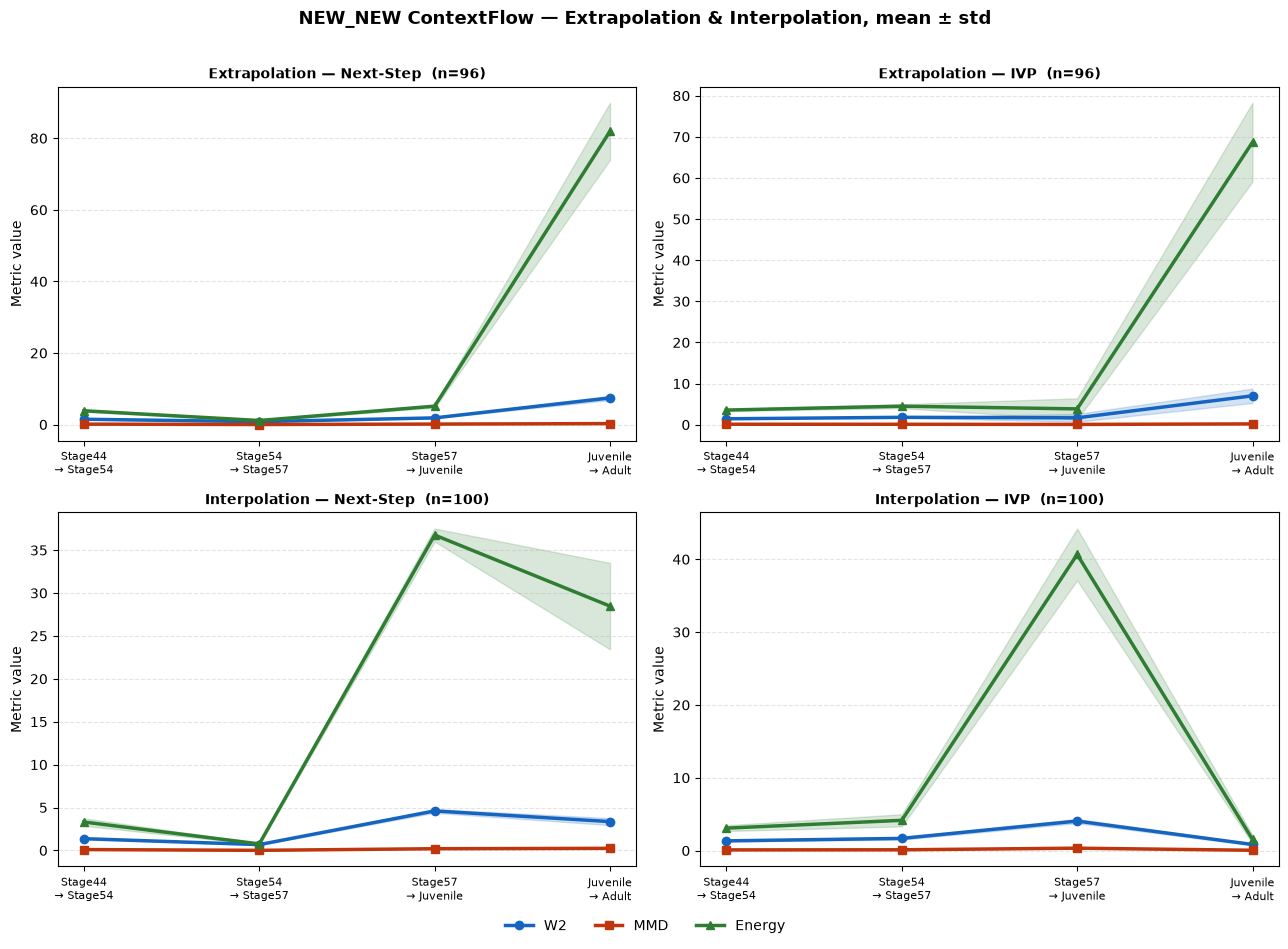

Saved: results/new_new_ctf_standalone_overview.png


In [32]:
plot_ctf_standalone(
    panels=[
        (nn_extrap_ns,  "Extrapolation — Next-Step"),
        (nn_extrap_ivp, "Extrapolation — IVP"),
        (nn_interp_ns,  "Interpolation — Next-Step"),
        (nn_interp_ivp, "Interpolation — IVP"),
    ],
    suptitle="NEW_NEW ContextFlow — Extrapolation & Interpolation, mean ± std",
    save_path=os.path.join(SCFLOW_RESULTS, "new_new_ctf_standalone_overview.png"),
)

## Relative Extrapolation & Interpolation

1. Calculate the deltas
2. (contextflow results) - (sc-flow_result) = delta
3. setup-repo is the current jax branch
4. Try to run jax and see if it works (maybe lot of bugs) (different branch PR to setup repo)

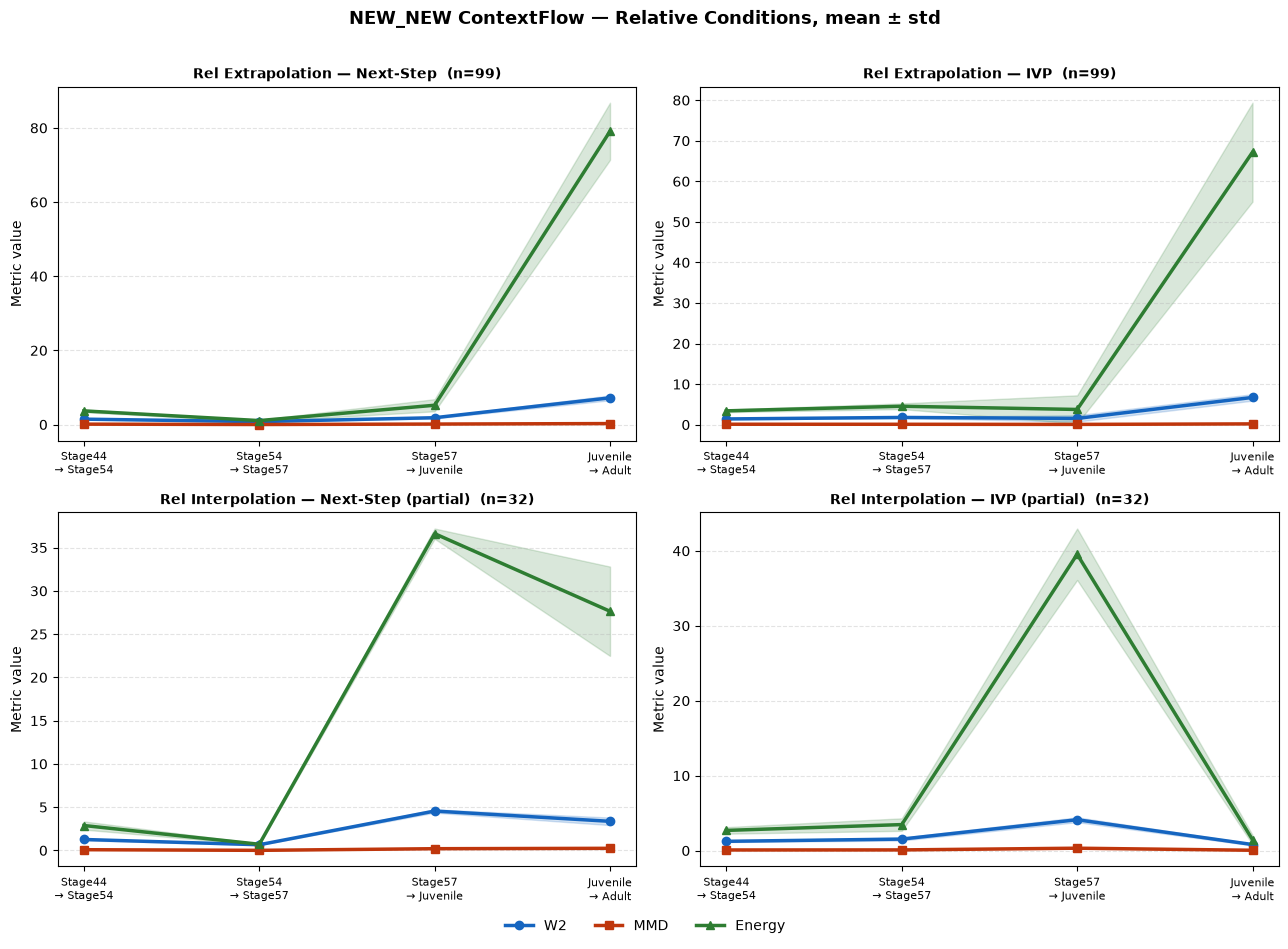

Saved: results/new_new_ctf_standalone_relative.png


In [33]:
plot_ctf_standalone(
    panels=[
        (nn_rel_extrap_ns,  "Rel Extrapolation — Next-Step"),
        (nn_rel_extrap_ivp, "Rel Extrapolation — IVP"),
        (nn_rel_interp_ns,  "Rel Interpolation — Next-Step (partial)"),
        (nn_rel_interp_ivp, "Rel Interpolation — IVP (partial)"),
    ],
    suptitle="NEW_NEW ContextFlow — Relative Conditions, mean ± std",
    save_path=os.path.join(SCFLOW_RESULTS, "new_new_ctf_standalone_relative.png"),
)